<a href="https://colab.research.google.com/github/tishhapatel/Advance-DataScience-and-ML/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import Libraries

In [1]:
# Install if needed (Colab usually has these)
!pip install numpy pandas matplotlib scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM

Create Synthetic Cybersecurity Dataset

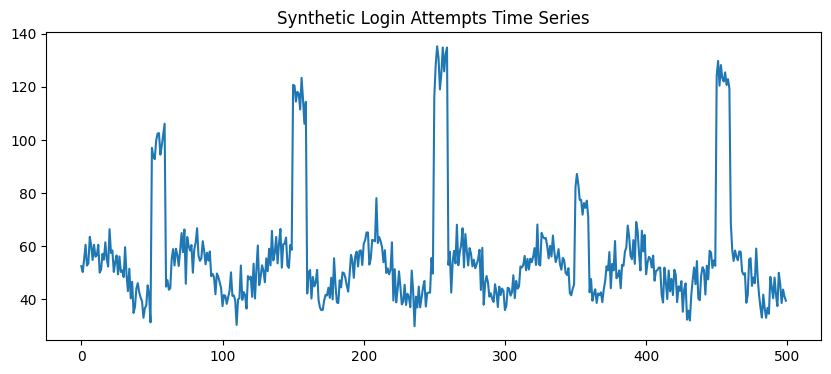

In [2]:
# Generate synthetic time series (login attempts)
np.random.seed(42)

time_steps = 500
time = np.arange(time_steps)

# Normal behavior + periodic pattern + random noise
login_attempts = 50 + 10*np.sin(0.1*time) + np.random.normal(0, 5, time_steps)

# Add attack spikes
for i in range(50, 500, 100):
    login_attempts[i:i+10] += np.random.randint(30, 80)

# Create DataFrame
data = pd.DataFrame({"login_attempts": login_attempts})

# Plot
plt.figure(figsize=(10,4))
plt.plot(data)
plt.title("Synthetic Login Attempts Time Series")
plt.show()

Normalize Data

In [3]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

Create Sequences (Lag Data)

In [4]:
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(scaled_data, seq_length)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

Build RNN Model

In [5]:
rnn_model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')

# Train
rnn_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0623
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0193
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0140
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0128
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0119
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0113
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0109
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0100
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0095
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093
Epoch 16/20
25/25 ━

Build LSTM Model

In [6]:
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

# Train
lstm_model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0643
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0262
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0239
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0221
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0198
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0182
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0161
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0150
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0132
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0130
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0130
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0125
Epoch 13/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0122
Epoch 14/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0132
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0123
Epoch 16/20


Predictions

In [7]:
# RNN Predictions
rnn_preds = rnn_model.predict(X_test)

# LSTM Predictions
lstm_preds = lstm_model.predict(X_test)

# Inverse scaling
rnn_preds = scaler.inverse_transform(rnn_preds)
lstm_preds = scaler.inverse_transform(lstm_preds)
y_test_actual = scaler.inverse_transform(y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


Plot Results

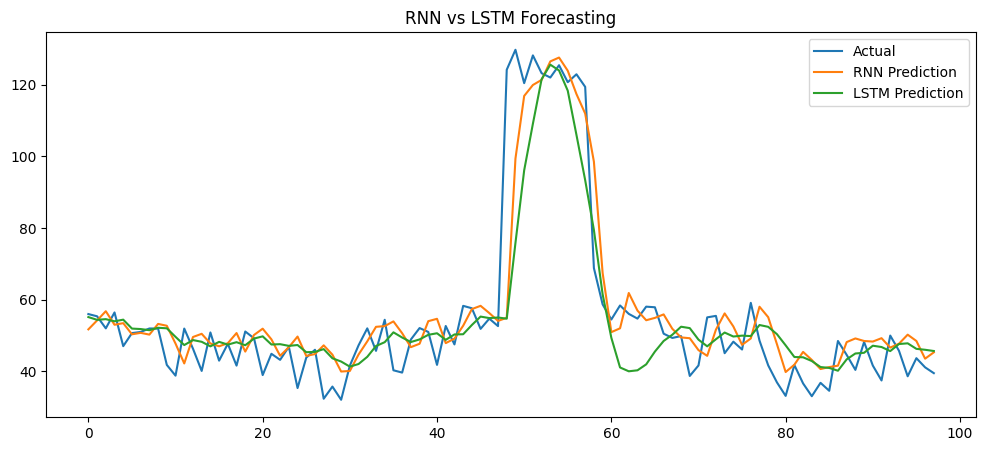

In [8]:
plt.figure(figsize=(12,5))

plt.plot(y_test_actual, label="Actual")
plt.plot(rnn_preds, label="RNN Prediction")
plt.plot(lstm_preds, label="LSTM Prediction")

plt.legend()
plt.title("RNN vs LSTM Forecasting")
plt.show()

Future Forecast Example

In [9]:
# Take last sequence
last_seq = X_test[-1]

future_steps = 10
future_preds = []

current_seq = last_seq

for _ in range(future_steps):
    pred = lstm_model.predict(current_seq.reshape(1, seq_length, 1))
    future_preds.append(pred[0][0])

    # update sequence
    current_seq = np.append(current_seq[1:], pred, axis=0)

# Convert back
future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))

print("Future Login Attempts Forecast:")
print(future_preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Future Login Attempts Forecast:
[[45.69285 ]
 [46.43755 ]
 [47.028584]
 [48.010605]
 [48.814434]
 [49.38764 ]
 [50.39367 ]
 [51.29395 ]
 [51.850925]
 [52.47992 ]]
